In [1]:
import string
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as pt
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer ,TfidfTransformer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

In [3]:
messages = [line.rstrip() for line in open('SMSSpamCollection')]
messages = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'message'])
messages['length'] = messages['message'].apply(len)

In [17]:
def visualize():
    sb.set_style('white')
    messages.hist(column='length', by='label', figsize=(12, 4), bins=50)
    pt.show()

In [18]:
#Function which will convert the text documents into list of tokens -> Tokenization
def tokenization(mes):
    nopunc = [line for line in mes if mes not in string.punctuation]
    nopunc = ''.join(nopunc)

    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]


In [19]:
#Split the dataset to training and testing 
X = messages['message']
y = messages['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [32]:
#Create the pipeline to multiple process like vectorization -> calculating TfIdf -> Classify the classes
pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=tokenization)),
    ('tfidf', TfidfTransformer()),
    ('classifier', MultinomialNB())
])

In [33]:
#Train the model and predict the instances
pipeline.fit(X_train, y_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function tokenization at 0x00000199934D3420>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

In [34]:
prediction = pipeline.predict(X_test)

In [35]:
#Complete report after prediction with message dataset
def generate_report():
    print(classification_report(y_test, prediction))
    print('\n')
    print(confusion_matrix(y_test, prediction))
    print('\n')
    print(accuracy_score(y_test, prediction))

In [36]:
generate_report()

              precision    recall  f1-score   support

         ham       0.95      1.00      0.97      1448
        spam       0.99      0.63      0.77       224

    accuracy                           0.95      1672
   macro avg       0.97      0.81      0.87      1672
weighted avg       0.95      0.95      0.94      1672



[[1447    1]
 [  83  141]]


0.9497607655502392


Report of Prediction : spam


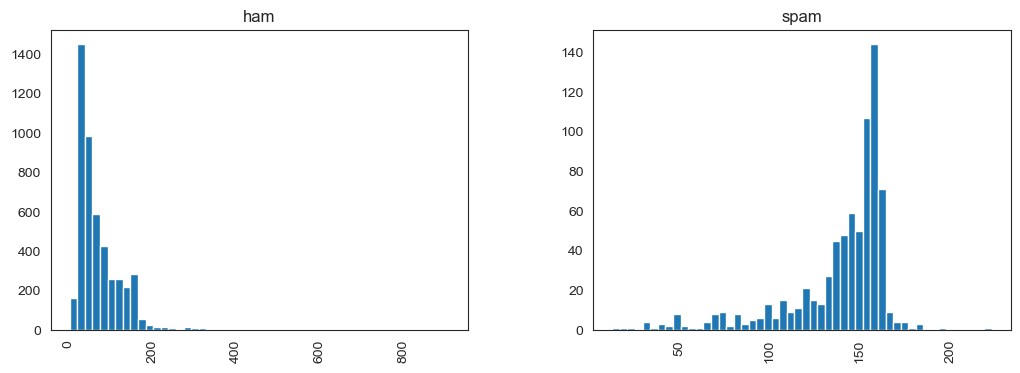

In [37]:
#Sample test
message_test = ["Congratulations! You won a free ticket. Call now!"]
result = pipeline.predict(message_test)
print('Report of Prediction :',result[0])
visualize()